In [ ]:
import copy
from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import DataLoader, ConcatDataset
from neuralop.data.datasets.tensor_dataset import TensorDataset

from conformal_no.data.datasets import SubsampleDataset, make_splits
from conformal_no.training.conformal_fno import load_uqfno

from experiments.expkit.datasets import load_darcy
from experiments.expkit.paths import CHECKPOINT_DIR
from experiments.expkit.style import set_style
from experiments.expkit.visualise import visualise
from experiments.expkit.plotting import (
    save_figure, plot_resampled_lambda, plot_coverage_histogram, 
    plot_coverage_violins, plot_coarse_fine
)
from experiments.expkit.build_results import build_results

from configs import (RESOLUTIONS, CONFIGS, SPLIT_SIZES, SEED, MODEL_VERSION,
                     N_CAL_RESAMPLE, N_RESAMPLES)


In [3]:
set_style()

EXPERIMENT_NAME = "darcy"
RESULTS_PATH = Path("results") / "results_df.pkl"

# Set True to re-run the experiments (slow). False loads cached results.
RECOMPUTE = False

device = torch.device("cpu")

In [4]:
raw = load_darcy()
predictor_dataset, error_dataset, calibration_dataset = make_splits(
    raw["train"], SPLIT_SIZES, seed=SEED
)
test_dataset = TensorDataset(*raw["test"])

In [5]:
loaders = {
    res: {
        "calib": DataLoader(SubsampleDataset(calibration_dataset, res),
                            batch_size=CONFIGS[res]["batch_size"], shuffle=False),
        "test": DataLoader(SubsampleDataset(test_dataset, res),
                           batch_size=CONFIGS[res]["batch_size"], shuffle=False),
    }
    for res in RESOLUTIONS
}

In [6]:
CALIBRATION_METHODS = {
    "Ours": lambda m, loader, cfg: m.conformal_calibrate(loader, alpha=cfg["alpha"]),
    "Ma et al.": lambda m, loader, cfg: m.ma_conformal_calibrate(loader, alpha=cfg["alpha"]),
}

models = {}
for res in RESOLUTIONS:
    fitted = load_uqfno(
        CONFIGS[res],
        CHECKPOINT_DIR / f"{EXPERIMENT_NAME}_uqfno_{res}_v{MODEL_VERSION}.pt",
        device,
    )
    for method in CALIBRATION_METHODS:
        models[(method, res)] = copy.deepcopy(fitted)

for (method, res), model in models.items():
    CALIBRATION_METHODS[method](model, loaders[res]["calib"], CONFIGS[res])

In [7]:
if RECOMPUTE:
    combined_dataset = ConcatDataset([test_dataset, calibration_dataset])
    combined_loaders = {
        res: DataLoader(SubsampleDataset(combined_dataset, res),
                        batch_size=CONFIGS[res]["batch_size"], shuffle=False)
        for res in RESOLUTIONS
    }

    FINE = 420
    interp_loaders = {
        res: DataLoader(SubsampleDataset(test_dataset, res, output_resolution=FINE),
                        batch_size=CONFIGS[res]["batch_size"], shuffle=False)
        for res in RESOLUTIONS
    }
    finest_loader = DataLoader(SubsampleDataset(test_dataset, FINE),
                               batch_size=4, shuffle=False)  # memory at 420^2

    results_df = build_results(
        models, loaders, combined_loaders, interp_loaders, finest_loader,
        CONFIGS, RESOLUTIONS,
        n_cal_resample=N_CAL_RESAMPLE, n_resamples=N_RESAMPLES, seed=SEED,
    )
    RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    results_df.to_pickle(RESULTS_PATH)
else:
    results_df = pd.read_pickle(RESULTS_PATH)

results_df

,method,resolution,mean bandwidth,scale factor,coverage zero-shot,coverage interpolated,coverage counts,resampled lambda
0,Ours,12,0.000943,1.842584,0.0,0.000,"[914, 904, 886, 904, 858, 913, 902, 915, 910, ...","[1.8994548320770264, 1.8812966346740723, 1.849..."
1,Ours,20,0.000690,1.591856,0.0,0.000,"[882, 890, 905, 903, 869, 858, 911, 910, 889, ...","[1.5600610971450806, 1.5690178871154785, 1.584..."
2,Ours,30,0.000552,1.484454,0.0,0.000,"[874, 896, 885, 907, 887, 905, 890, 922, 885, ...","[1.454526424407959, 1.475473403930664, 1.46517..."
3,Ours,42,0.000462,1.641036,0.0,0.000,"[872, 890, 885, 884, 885, 878, 891, 931, 903, ...","[1.6241264343261719, 1.6452209949493408, 1.638..."
4,Ours,60,0.000541,1.417301,0.0,0.015,"[887, 871, 894, 882, 883, 908, 916, 939, 876, ...","[1.4215396642684937, 1.4065556526184082, 1.425..."
5,Ours,84,0.000504,1.535151,0.0,0.838,"[879, 899, 897, 879, 908, 897, 913, 917, 870, ...","[1.4911999702453613, 1.5083876848220825, 1.507..."
6,Ma et al.,12,0.002240,4.375731,0.0,0.000,"[1000, 1000, 1000, 1000, 1000, 1000, 1000, 100...","[4.033509731292725, 4.783439636230469, 4.20405..."
7,Ma et al.,20,0.000971,2.239827,0.0,0.000,"[992, 997, 993, 994, 992, 995, 997, 997, 993, ...","[2.1907849311828613, 2.2296955585479736, 2.236..."
8,Ma et al.,30,0.000713,1.918674,0.0,0.000,"[988, 989, 989, 991, 988, 992, 987, 991, 985, ...","[1.8570032119750977, 1.8506683111190796, 1.897..."
9,Ma et al.,42,0.000577,2.048821,0.0,0.045,"[971, 987, 975, 978, 978, 973, 981, 987, 983, ...","[2.0030953884124756, 2.0869288444519043, 2.048..."


RMS  true solution 0.04266  predicted solution 0.0423
RMS  true error 0.0005097  predicted error 0.0008005


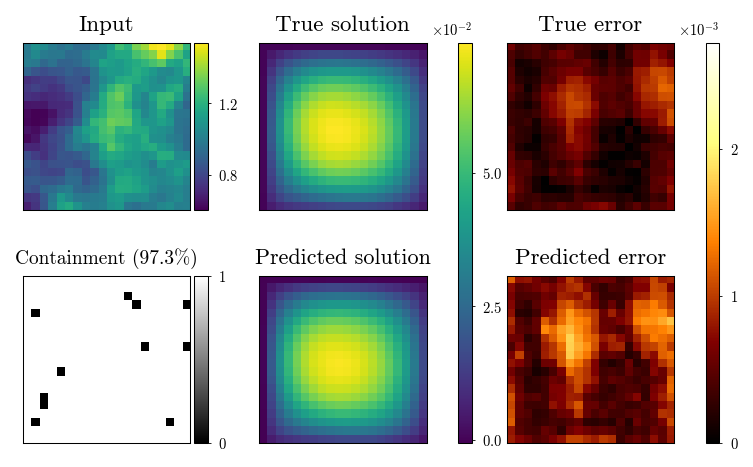

In [10]:
res = 20
fig = visualise(
    loaders[res]["test"], models[("Ours", res)], separate_input_scale=True,
    error_vmax_scale=1.5, verbose=True
)

In [11]:
save_figure(fig, f"coarse_visualisation_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/darcy/coarse_visualisation_darcy.pdf


RMS  true solution 0.04174  predicted solution 0.04172
RMS  true error 0.0002667  predicted error 0.0004725


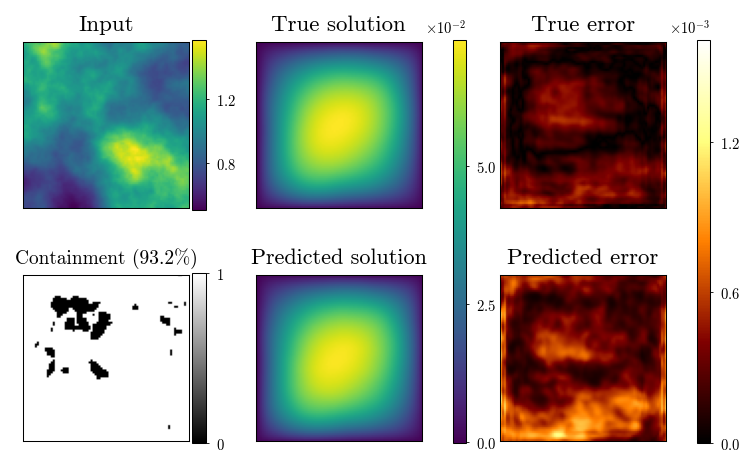

In [23]:
res = 84
fig = visualise(
    loaders[res]["test"], models[("Ours", res)], separate_input_scale=True,
    error_vmax_scale=1.3, verbose=True
)

In [24]:
save_figure(fig, f"fine_visualisation_{EXPERIMENT_NAME}", subdir=EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/darcy/fine_visualisation_darcy.pdf


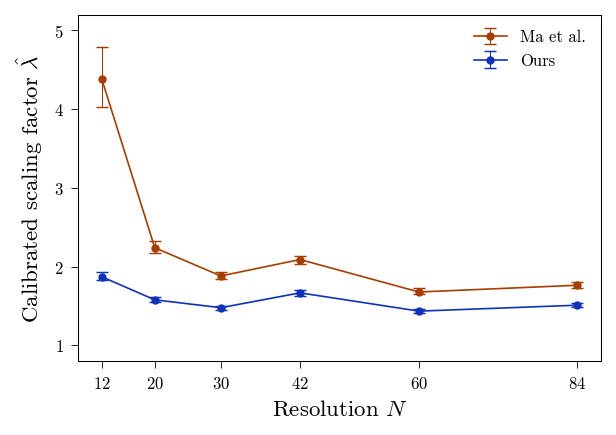

In [15]:
fig = plot_resampled_lambda(results_df, ylim=(0.8, 5.2), yticks=[1, 2, 3, 4, 5])

In [16]:
save_figure(fig, f"resampled_lambda_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/darcy/resampled_lambda_darcy.pdf


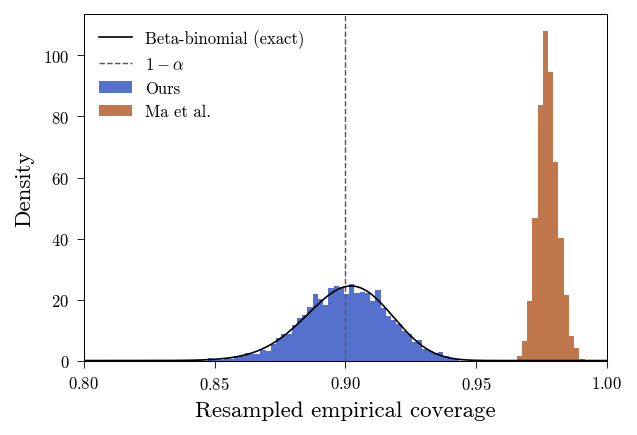

In [18]:
n_test = len(test_dataset) + len(calibration_dataset) - N_CAL_RESAMPLE
alpha = CONFIGS[RESOLUTIONS[0]]["alpha"]

fig = plot_coverage_histogram(results_df, resolution=60, n_cal=N_CAL_RESAMPLE, 
                              n_test=n_test, alpha=alpha, bin_width=2, 
                              xticks=[0.8, 0.85, 0.9, 0.95, 1])

In [19]:
save_figure(fig, f"coverage_histogram_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/darcy/coverage_histogram_darcy.pdf


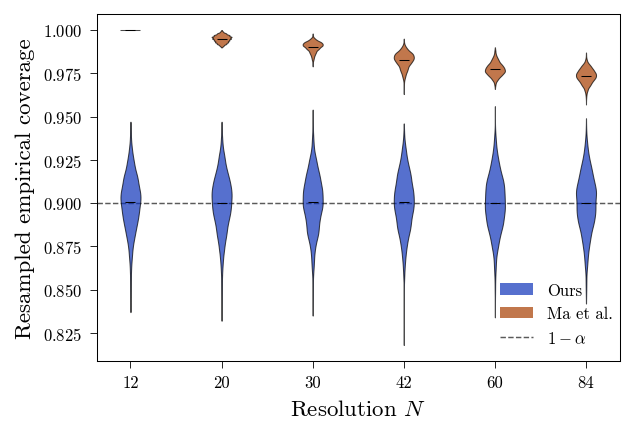

In [20]:
fig = plot_coverage_violins(results_df, n_test=n_test, alpha=alpha, 
                            legend_shift=-0.015)

In [21]:
save_figure(fig, f"violins_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/darcy/violins_darcy.pdf


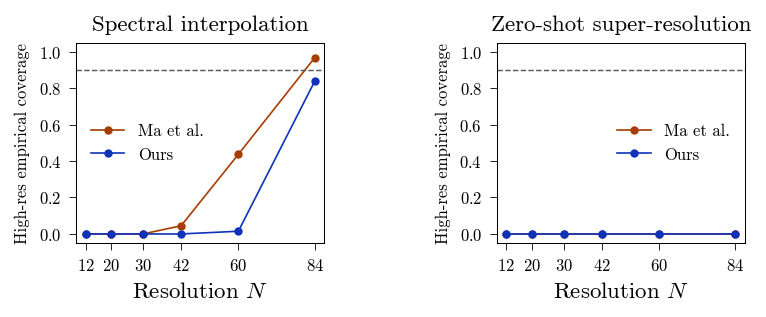

In [22]:
fig = plot_coarse_fine(results_df, alpha=alpha, xlim=(9, 87))

In [23]:
save_figure(fig, f"coarse_fine_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/darcy/coarse_fine_darcy.pdf
